## Evaluation Demo

In this workbook, you can reproduce the figures which we include in our paper. In particular, we demonstrate the following tests:

1. Input sequence length evaluation              ✅
2. Triplet vs. quadruplet training loss function ✅ -- but the results of this comparison aren't great (both are amazing) -- need to find worse scenarios
3. Fingerprint's temporal consistency            ✅ -- but we need to refactor everything to make it look more pretty
4. Multi-RX fingerprinting                       ⏳ -- practically the same thing as (2), but: multi-RX weight-based evaluation
5. Dataset confusion matrices                    ⏳ -- same as (4), but for both closed set and open set, and multi-RX weight-based

Requirements:

* Software: Matlab (tested with R2024a)
* Datasets: `DatasetAPI.DATASET_V2` and `DatasetAPI.DATASET_V4`

In [22]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import matlab
from dataset_api import DatasetAPI
from extractor_api import ExtractorAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI

In [23]:
ROOT_DIRECTORY = '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY = '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/lora_rffi_working'
MATLAB_SESSION_ID = 'fp_workflow'

RX_NODES_V2 = [DatasetAPI.RX_1, DatasetAPI.RX_2, DatasetAPI.RX_3, DatasetAPI.RX_4]
DATA_CONFIG_V2 = {
    'dataset_name': DatasetAPI.DATASET_V2,
    'frame_count_train': 200, # 200 for v2, 500 for v3
    'frame_count_epoch': 100,
    'samples_count': 400
}

AUG_CONFIG = {
    'multiplier': 5,
    't_rms_bounds': matlab.double([1, 2]),
    'd_f_bounds': matlab.double([0, 10]),
    'k_factor_bounds': matlab.double([0, 10]),
    'awgn': matlab.double([10, 50]),
}

MODEL_CONFIG = {
    'batch_size': 32,
    # 'loss_type': 'triplet_loss', 'loss_num_neg': 1,
    'loss_type': 'quadruplet_loss', 'loss_num_neg': 2,
    #  'loss_type': 'quintuplet_loss', 'loss_num_neg': 3,
    # 'loss_type': 'n_loss', 'loss_num_neg': 2,
    'npair_type': 'samedev',
    # 'npair_type': 'diffdev',
    'alpha': 1.0, # used only for triple & quadruple loss
    'patience': 10,
    'fp_len': 512,
    'row': 50
}

In [24]:
extractor_api = ExtractorAPI()
dataset_api = DatasetAPI(
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=False)
fp_api = FingerprintingAPI(
    rx_ids = RX_NODES_V2, 
    data_config=DATA_CONFIG_V2, 
    aug_config=AUG_CONFIG,
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=False)
eval_api = EvaluationAPI(
    rx_ids = RX_NODES_V2, 
    data_config=DATA_CONFIG_V2, 
    aug_config=AUG_CONFIG, 
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=False)

### 1. The impact of the preamble

To train the fingerprint extractor, we are using preambles of 802.11 frames. This raises a few questions:

* Why preambles? Why can't we use other sections of an OFDM frame
* Even if we use preambles, shouldn't the model focus only on hardware imperfections? Why can't we use other sections to enroll/identify devices?

To answer these questions, we perform the following experiments:

1. We train the model on 802.11 preambles, and test enrollment/identification on sections of frames with a shifting start index;
2. Next, we also try training the model on non-preamble section of a frame (index 400-800), and repeat the same testing plan.
3. Importantly, since we're performing simple A/B tests, we only evaluate performance for a closed-set problem (via KNN classification), for a single receiver, and for only two epochs.

These results can let us answer the questions above:

* **Why preambles? Why can't we use other sections of an OFDM frame** -- because this is the only section of a frame that doesn't contain "random" data. We can see this by reviewing the 2nd figure. Since the model was trained on non-preamble samples, the max accuracy the model ever achieves is 65%, which is not acceptable.

* **Even if we use preambles, shouldn't the model focus only on hardware imperfections? Why can't we use other sections to enroll/identify devices?** -- The model doesn't extract only hardware imperfections. The fingerprints incorporate data-specific features as well, which makes it essential to use the exact same preamble section for training & testing.

Load the training dataset
Processing offset 0
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 1s 2ms/step
Accuracy: 99.67%
Processing offset 10
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 91.11%
Processing offset 20
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 96.33%
Processing offset 30
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 95.78%
Processing offset 40
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
29/29 [==============================] - 0s 2ms/step
Accuracy: 96

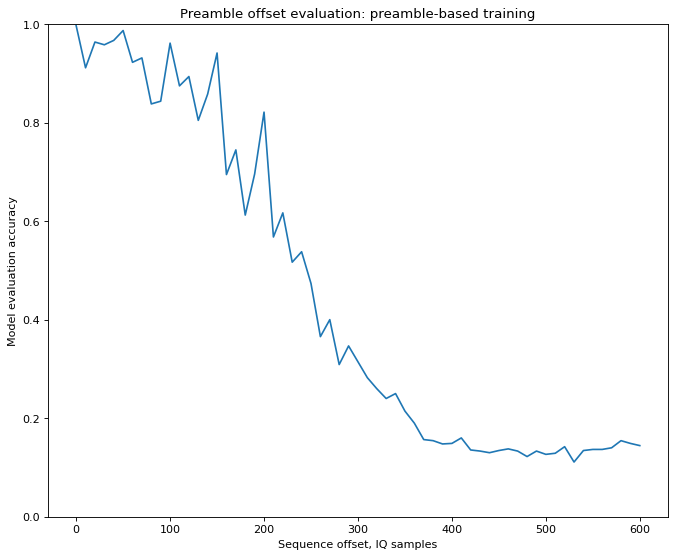

Load the training dataset
Applying quadruplet_loss
Epoch 1/1000
163/163 [==============================] - 6s 22ms/step - loss: 1.5020 - val_loss: 1.4979 - lr: 0.0010
Epoch 2/1000
163/163 [==============================] - 3s 19ms/step - loss: 1.4794 - val_loss: 1.4021 - lr: 0.0010
Epoch 3/1000
163/163 [==============================] - 3s 18ms/step - loss: 1.4526 - val_loss: 1.3855 - lr: 0.0010
Epoch 4/1000
163/163 [==============================] - 3s 20ms/step - loss: 1.4164 - val_loss: 1.3018 - lr: 0.0010
Epoch 5/1000
163/163 [==============================] - 4s 22ms/step - loss: 1.3514 - val_loss: 1.2734 - lr: 0.0010
Epoch 6/1000
163/163 [==============================] - 4s 22ms/step - loss: 1.2227 - val_loss: 1.1381 - lr: 0.0010
Epoch 7/1000
163/163 [==============================] - 4s 22ms/step - loss: 1.0566 - val_loss: 0.9441 - lr: 0.0010
Epoch 8/1000
163/163 [==============================] - 4s 22ms/step - loss: 0.8744 - val_loss: 0.6639 - lr: 0.0010
Epoch 9/1000
163/163 

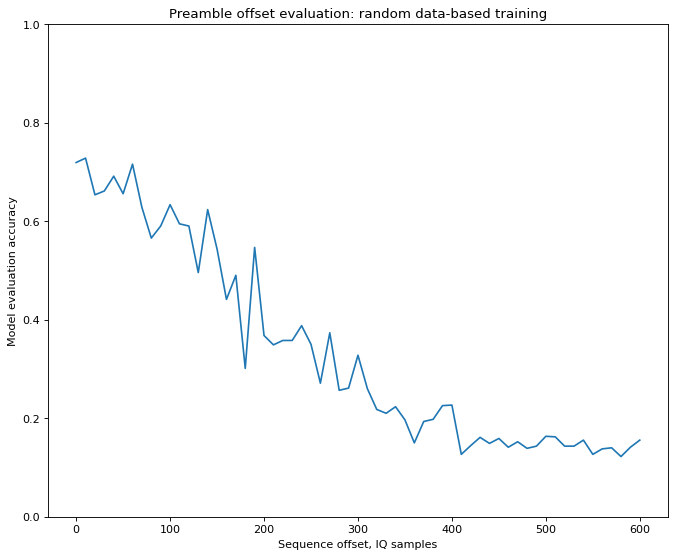

In [7]:
eval_api.evaluate_preamble_offset(rx_id=DatasetAPI.RX_1, frame_start_train=0, offset_range=np.arange(0, 610, 10), use_pretrained=True, fig_name="Preamble offset evaluation: preamble-based training")
eval_api.evaluate_preamble_offset(rx_id=DatasetAPI.RX_1, frame_start_train=400, offset_range=np.arange(0, 610, 10), use_pretrained=False, fig_name="Preamble offset evaluation: random data-based training")

### 2. Triplet vs. quadruplet training loss function

Every bit matters. Let's try adopting a quadruplet loss function and explore model performance on an identical dataset & settings.

Note: currently, the test is being performed under open-set conditions. You can override this by defining identical device ID sets in this function, and run closed-set test.

Load the training dataset
Evaluating for triplet_loss
Applying triplet_loss
Epoch 1/1000
163/163 [==============================] - 5s 18ms/step - loss: 0.1343 - val_loss: 0.0358 - lr: 0.0010
Epoch 2/1000
163/163 [==============================] - 2s 14ms/step - loss: 0.0231 - val_loss: 0.0200 - lr: 0.0010
Epoch 3/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0121 - val_loss: 0.0108 - lr: 0.0010
Epoch 4/1000
163/163 [==============================] - 2s 15ms/step - loss: 0.0057 - val_loss: 0.0073 - lr: 0.0010
Epoch 5/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0030 - val_loss: 0.0019 - lr: 0.0010
Epoch 6/1000
163/163 [==============================] - 2s 15ms/step - loss: 0.0022 - val_loss: 0.0028 - lr: 0.0010
Epoch 7/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0016 - val_loss: 5.0252e-04 - lr: 0.0010
Epoch 8/1000
163/163 [==============================] - 2s 14ms/step - loss: 0.0014 - val_loss: 0.0014 - lr:

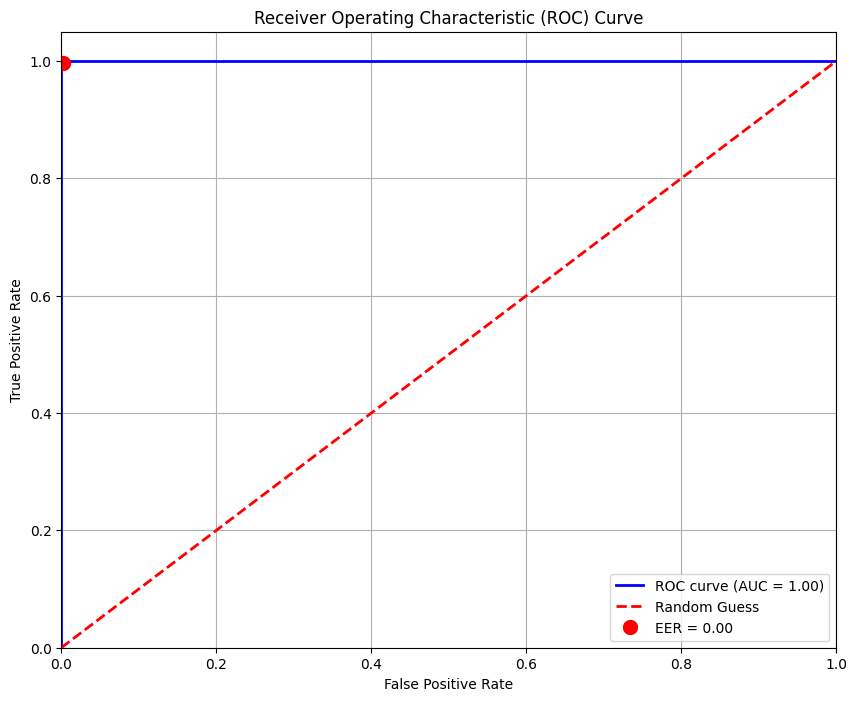

Evaluating for quadruplet_loss
Applying quadruplet_loss
Epoch 1/1000
163/163 [==============================] - 6s 21ms/step - loss: 0.3732 - val_loss: 0.1917 - lr: 0.0010
Epoch 2/1000
163/163 [==============================] - 3s 19ms/step - loss: 0.1328 - val_loss: 0.1169 - lr: 0.0010
Epoch 3/1000
163/163 [==============================] - 3s 21ms/step - loss: 0.0894 - val_loss: 0.0829 - lr: 0.0010
Epoch 4/1000
163/163 [==============================] - 4s 22ms/step - loss: 0.0574 - val_loss: 0.0421 - lr: 0.0010
Epoch 5/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0451 - val_loss: 0.0456 - lr: 0.0010
Epoch 6/1000
163/163 [==============================] - 3s 20ms/step - loss: 0.0325 - val_loss: 0.0221 - lr: 0.0010
Epoch 7/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0214 - val_loss: 0.0158 - lr: 0.0010
Epoch 8/1000
163/163 [==============================] - 3s 21ms/step - loss: 0.0142 - val_loss: 0.0107 - lr: 0.0010
Epoch 9/1000
163

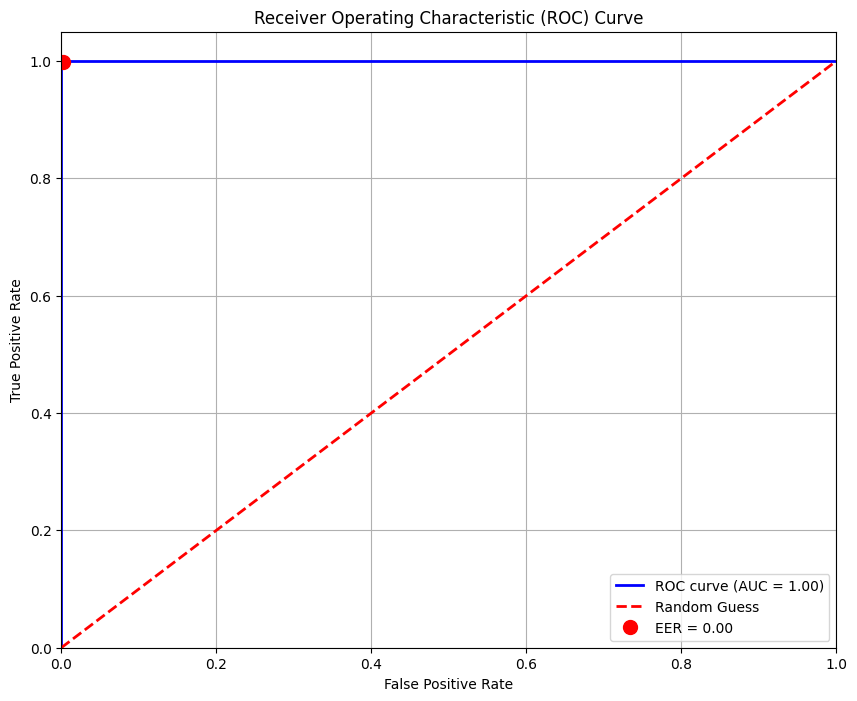

In [8]:
eval_api.evaluate_loss_function(rx_id = DatasetAPI.RX_1, render_confusion_matrix = True, render_roc_curve = True)

### 3. Fingerprint's temporal consistency

Generating eval finerprints for node1-1...
171
29/29 [==============================] - 0s 2ms/step
Generating eval finerprints for node1-20...
171
29/29 [==============================] - 0s 1ms/step
Generating eval finerprints for node20-1...
171
29/29 [==============================] - 0s 2ms/step
./home/smazokha2016/Desktop/orbit_dataset_v2_jul19/node20-1_epoch_2024-07-20_18-32-46.h5
index 0 is out of bounds for axis 0 with size 0
 1/29 [>.............................] - ETA: 0s

Traceback (most recent call last):
  File "/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/evaluation_api.py", line 236, in _produce_fingerprints
    data, label, rssi = self.dataset_api.filter_dataset(data, label, rssi, dev_range=node_ids_epoch, pkt_range=np.arange(0, self.data_config['frame_count_epoch']))
  File "/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/dataset_api.py", line 164, in filter_dataset
    frame_idx_device = np.where(labels==int(dev_idx))[0][pkt_range]
IndexError: index 0 is out of bounds for axis 0 with size 0


29/29 [==============================] - 0s 2ms/step
Generating eval finerprints for node19-19...
171
29/29 [==============================] - 0s 2ms/step


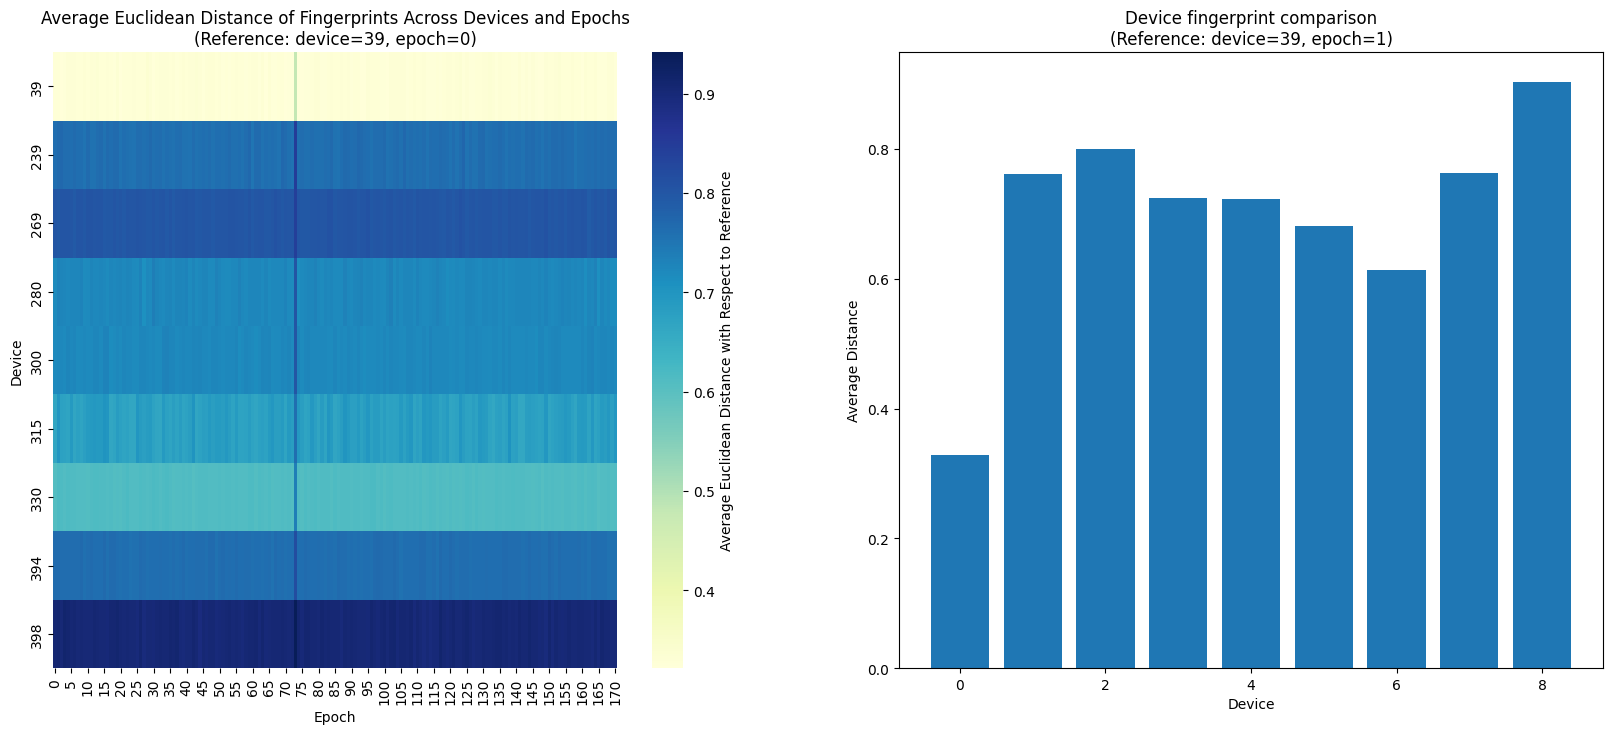

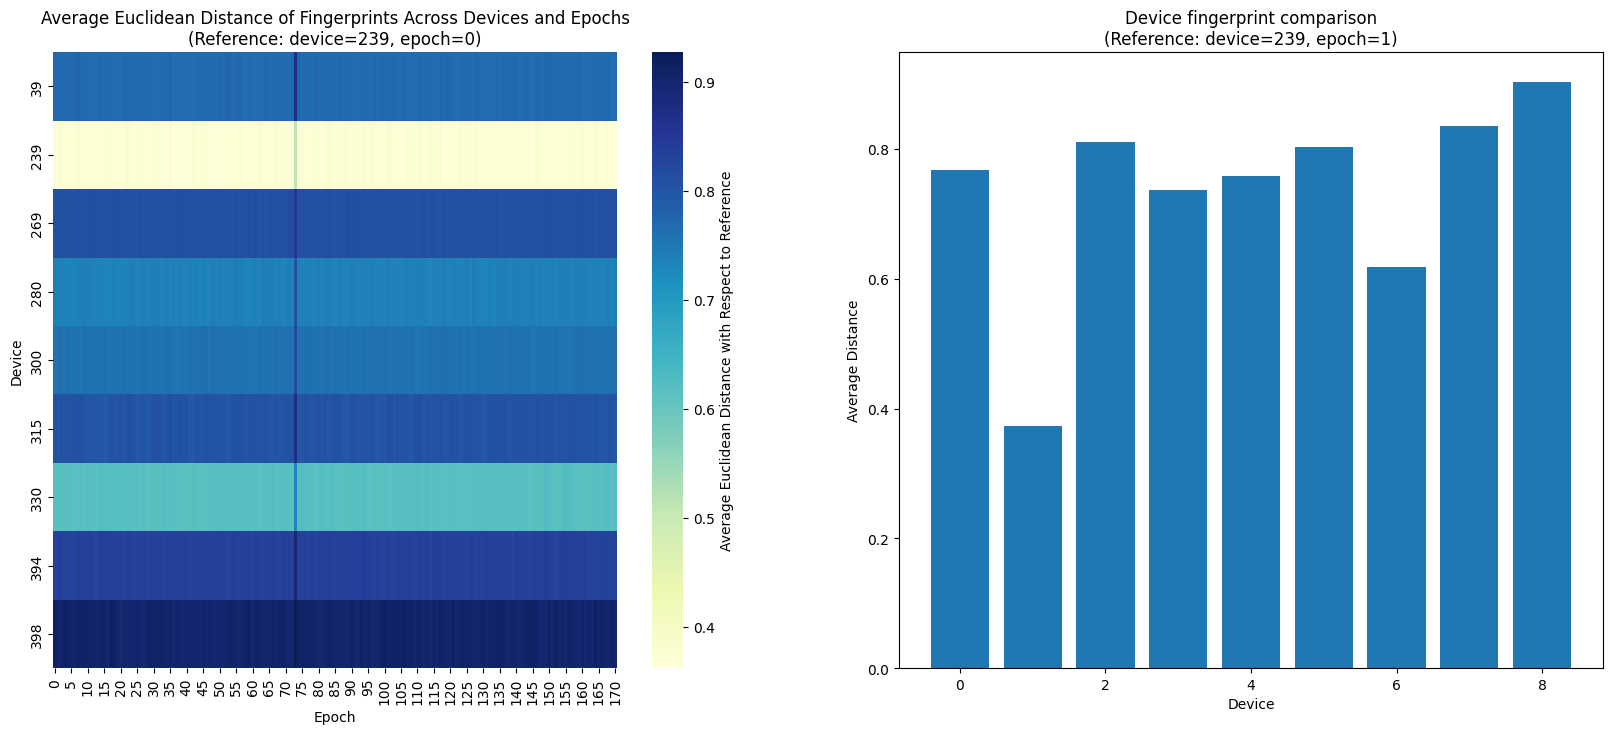

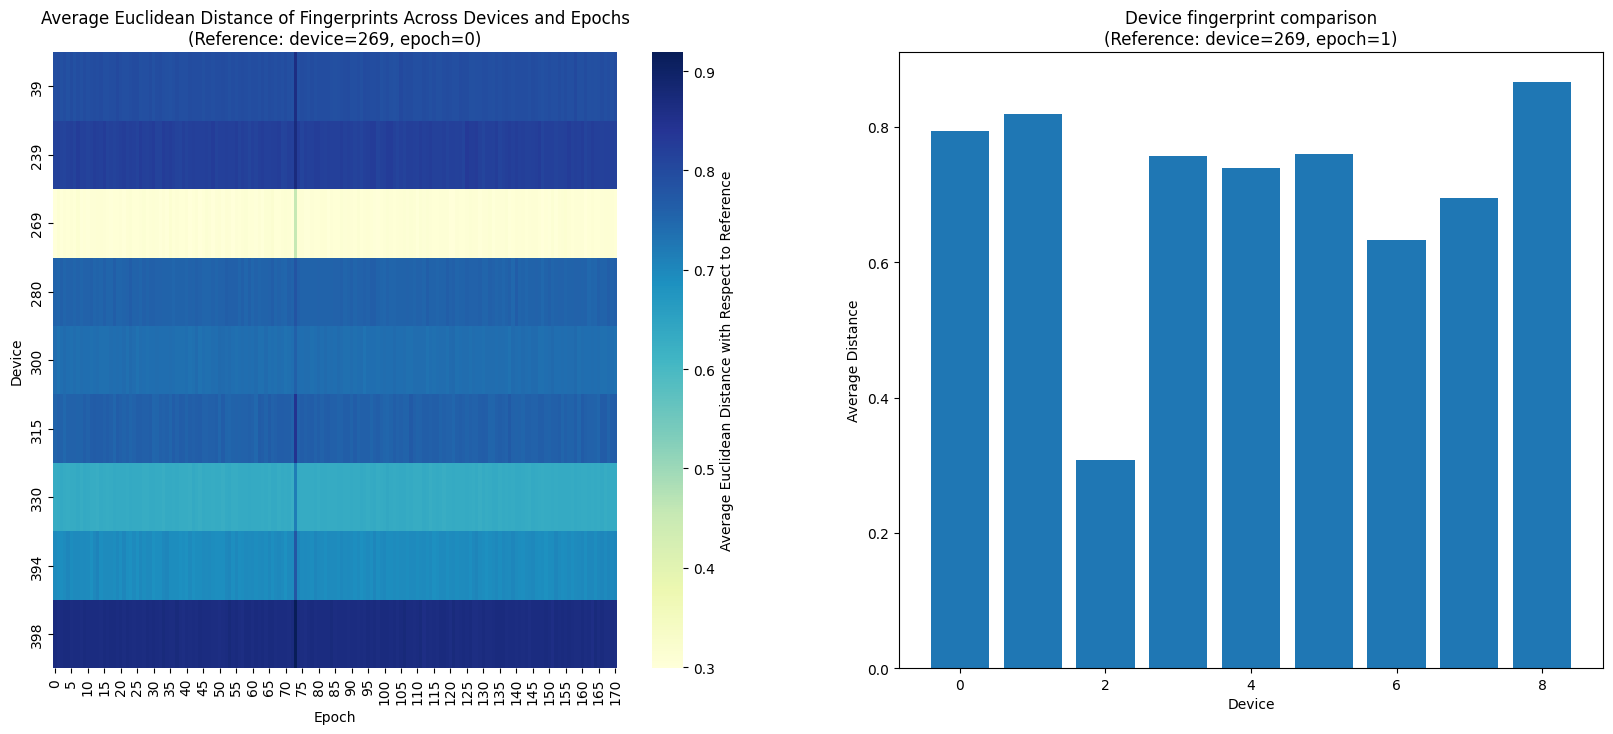

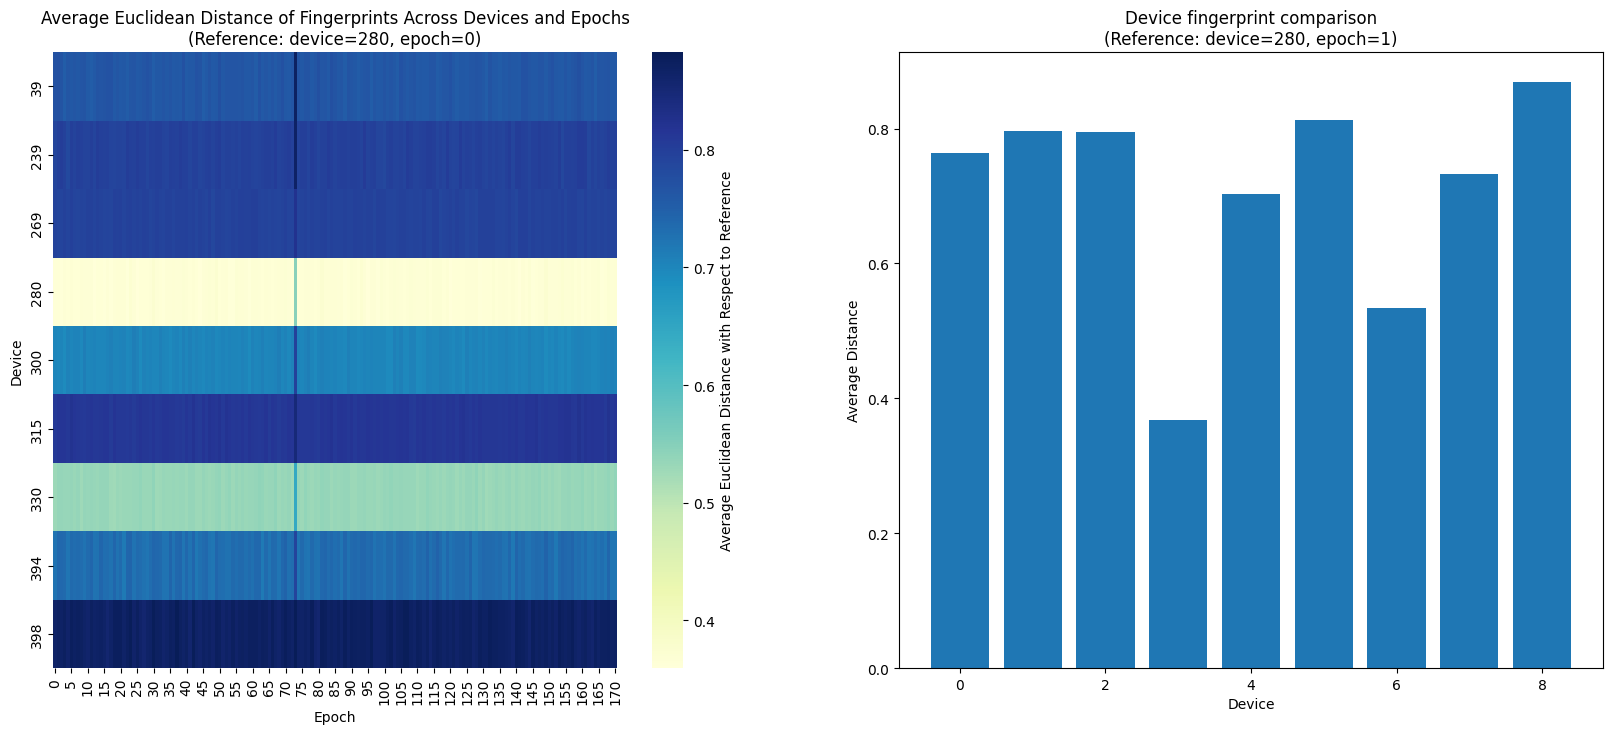

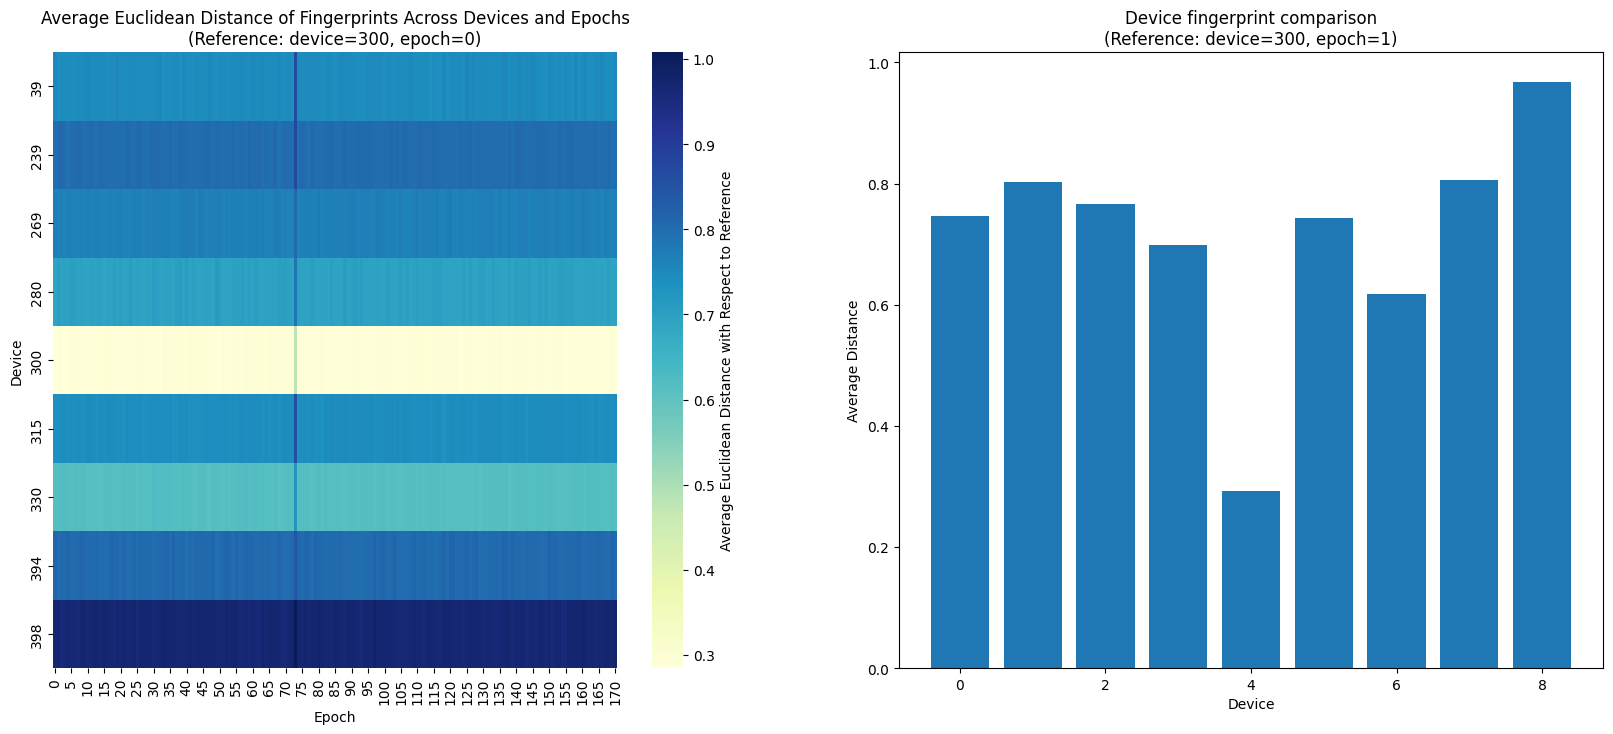

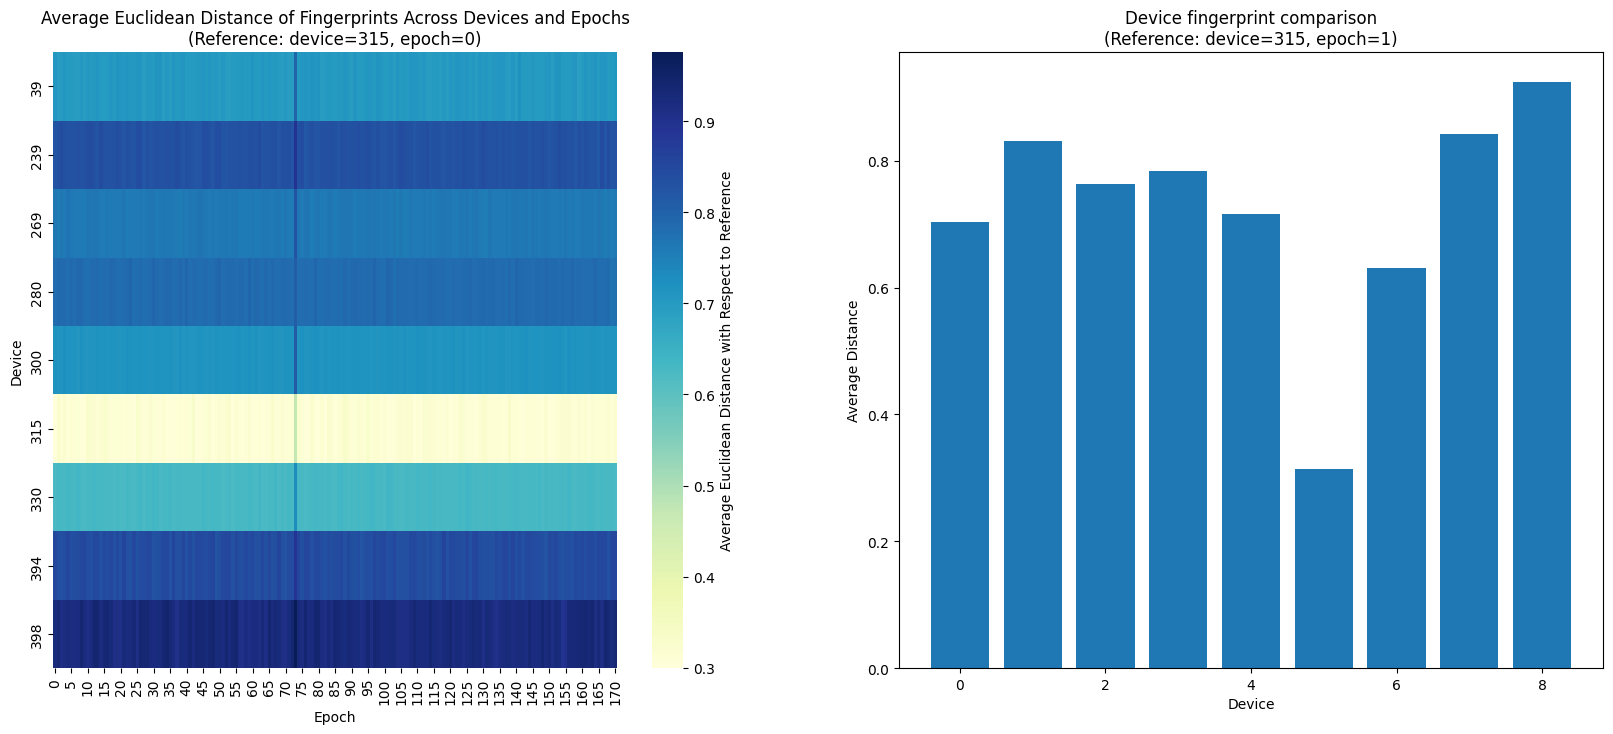

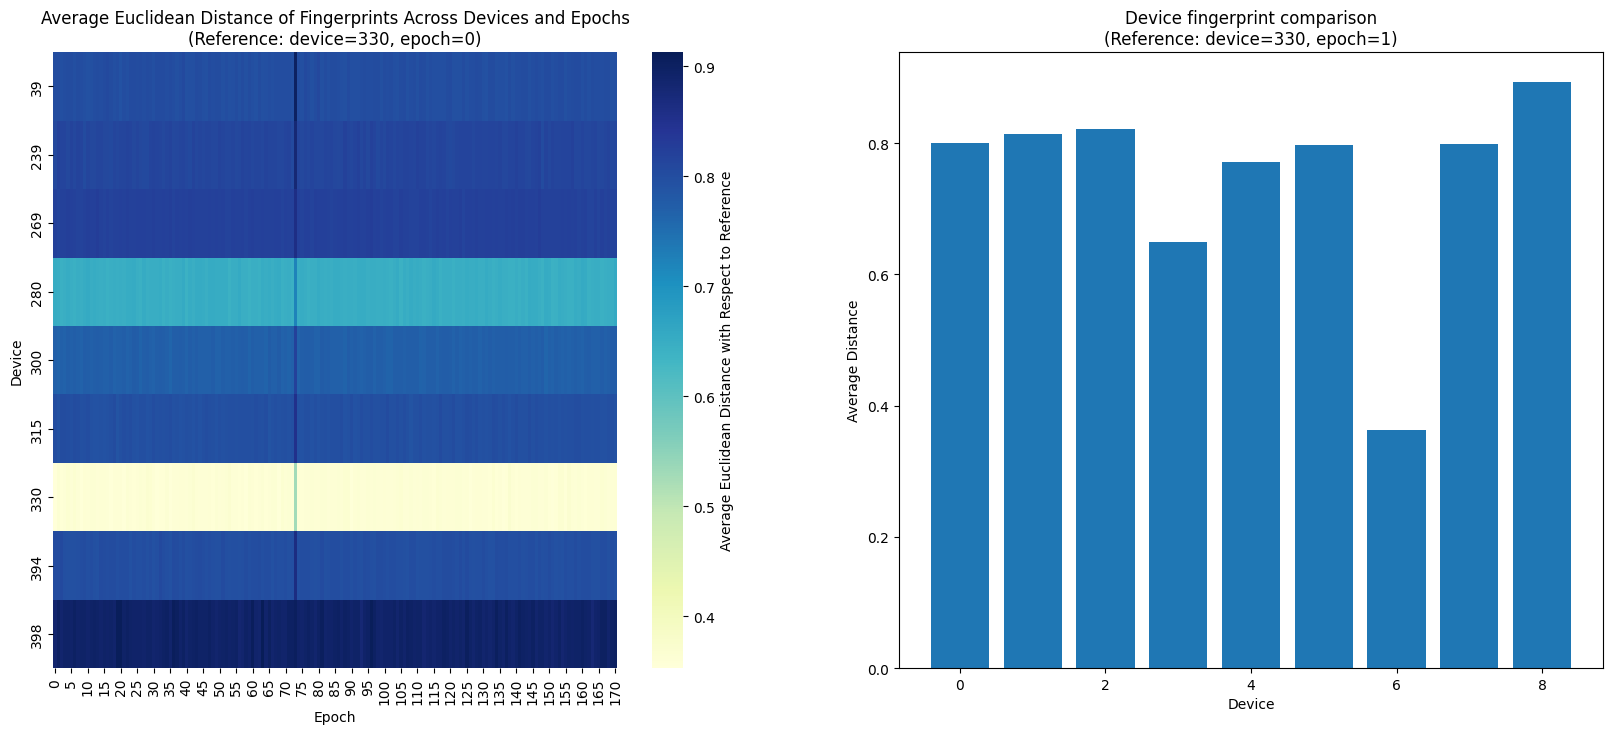

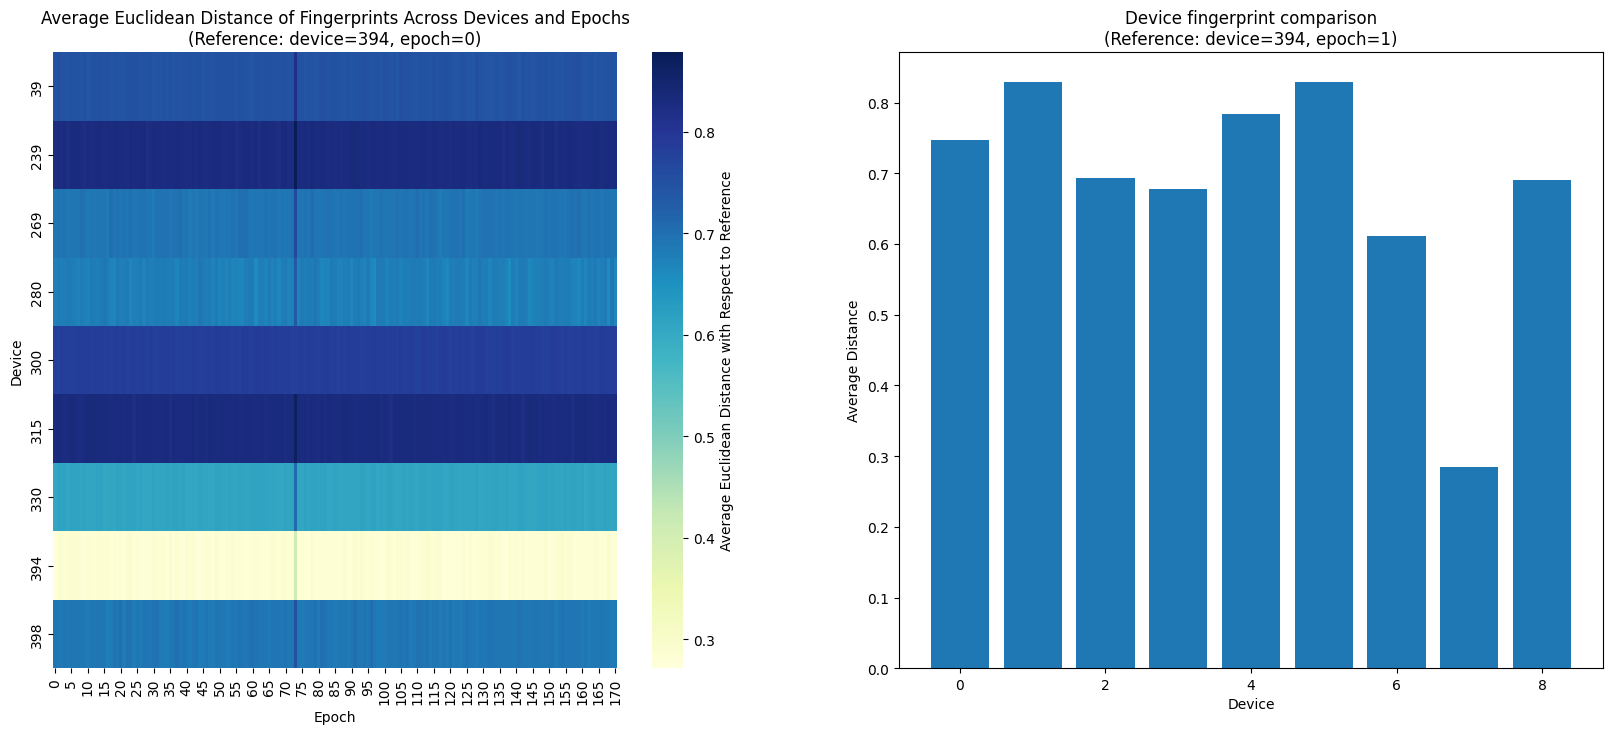

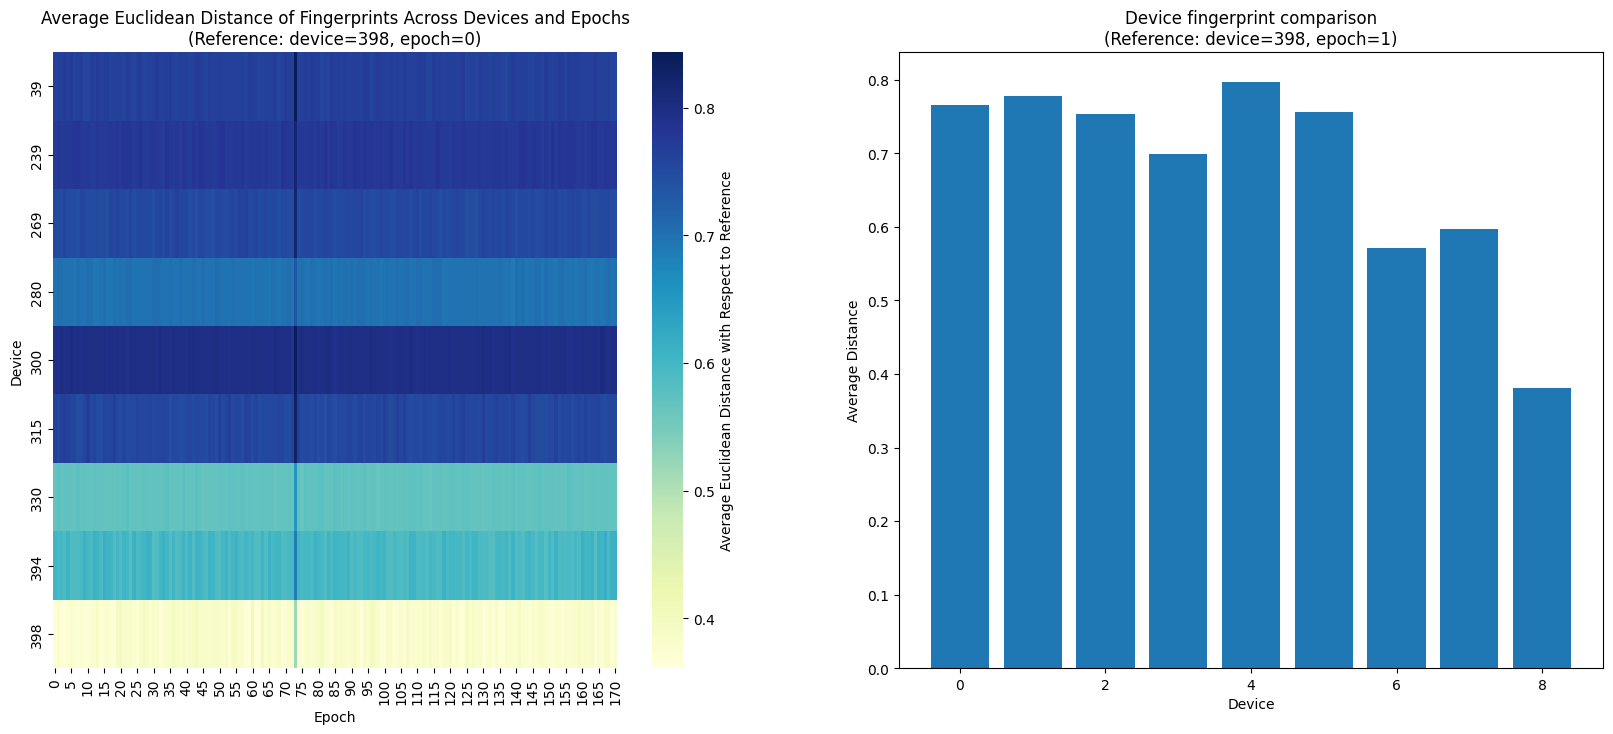

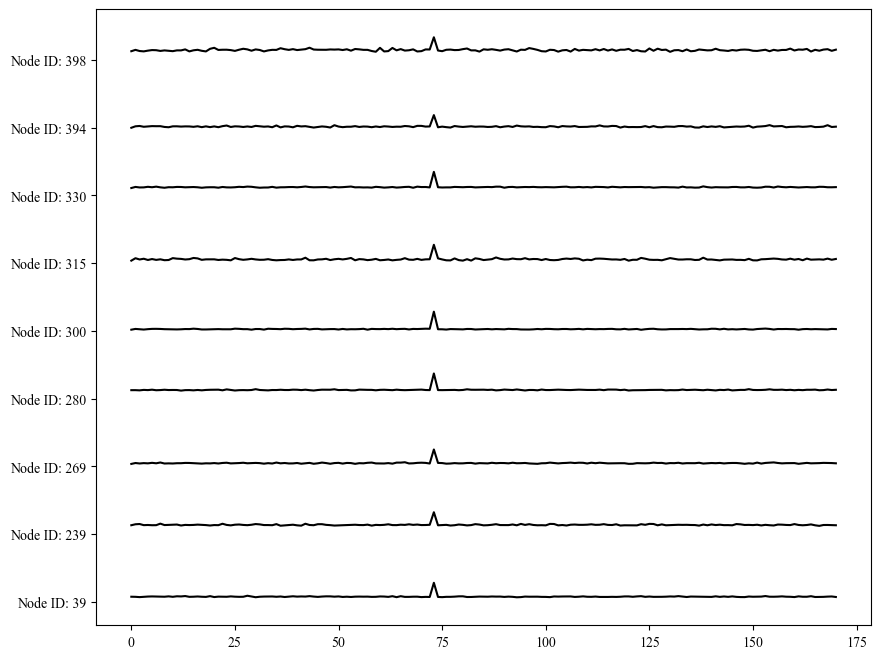

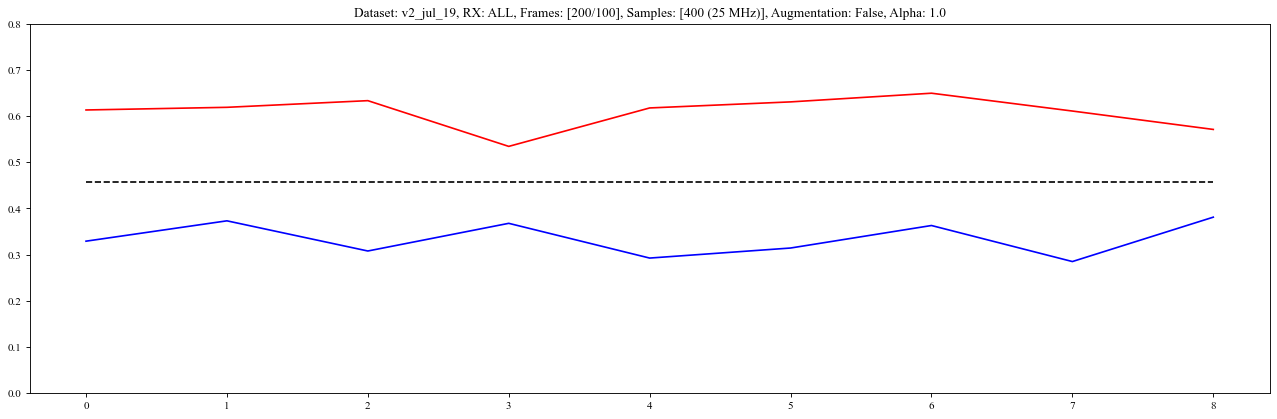

In [9]:
# models, _ = fp_api.train_models(apply_noise=False)
models = fp_api.load_models()

node_ids_epoch_override=[39, 239, 269, 280, 300, 315, 330, 394, 398]

fp_distances = eval_api.evaluate_temporal_stability(
    models, RX_NODES_V2, 
    node_ids_epoch_override, 
    epochs_override=None, show_fp_heatmaps=True, render_temporal_heatmap=False)

### 4. Multi-RX fingerprinting

The task here is slightly more interesting. While previously we evaluated the process of training the model, as well as whether the model can extract time-insensitive features -- now we can consider whether it's possible to improve the system performance by combining (aka fusing) fingerprints from multiple receivers that "hear" our signal simultaneously. 

This requires a slightly different process. Previous model tests could be performed while using a simple KNN-based evaluator. This step requires building out a custom evaluator, which is going to let us combine KNN distances with our custom weight factor -- RSSI (normalized between 0 and 1 on a -100 to 0 dB scale). 

Here's how this evaluation will work: 

1. We will build an evaluator which performs the evaluation process using a custom list of receivers. 
2. We will then run this evaluator for the following combinations:
    * RX 1
    * RX 2
    * RX 3
    * RX 4
    * RX 1, 2
    * RX 1, 2, 3
    * rX 1, 2, 3, 4
3. We will compare their performance on both closed-set and open-set scenarios, and produce the same accuracy metrics as before
4. Optionally, we will let the user render a rank 1-2 plot across all devices

In [5]:
from dataset_preparation import awgn

aug_on = False
apply_noise = False

epoch_idx_enroll = 0
epoch_idx_identify = 1

enroll_device_idx = [39, 239, 269, 280, 300]
identify_device_idx = [39, 239, 269, 280, 300, 315, 330, 394, 398]

frame_count_enroll = frame_count_identify = 100

models = {}
data_epochs_1 = {}
labels_epochs_1 = {}
data_epochs_2 = {}
labels_epochs_2 = {}
rssis_epoch_2 = {}

for rx_id in RX_NODES_V2:
    print("Load the training dataset")
    dataset_train_path, dataset_epoch_paths, model_path, node_ids_train, _, samp_rate = dataset_api.load_dataset_info(DATA_CONFIG_V2['dataset_name'], rx_id, None)
    if aug_on: data, label, rssi = dataset_api.load_augmented_dataset(dataset_train_path, samp_rate, AUG_CONFIG, shuffle=True)
    else: data, label, rssi = dataset_api.load_raw_dataset(dataset_train_path, shuffle=True)
    data, label, rssi = dataset_api.filter_dataset(data, label, rssi, node_ids_train, np.arange(0, DATA_CONFIG_V2['frame_count_train']))
    if apply_noise: data = awgn(data, np.arange(AUG_CONFIG['awgn'][0][0], AUG_CONFIG['awgn'][0][1]))
    data_train = data[:, 0:0+DATA_CONFIG_V2['samples_count']]

    # feature_extractor, _ = extractor_api.train(data_train, label, node_ids_train, MODEL_CONFIG, save_path=None)
    models[rx_id] = extractor_api.load(os.path.join(model_path, f"extractor_{rx_id}.keras"))

    # Load data (two epochs: one to enroll devices, another to identify devices)
    data_enroll, labels_enroll, rssi_enroll = dataset_api.load_raw_dataset(dataset_epoch_paths[epoch_idx_enroll], shuffle=True)
    data_identify, labels_identify, rssi_identify = dataset_api.load_raw_dataset(dataset_epoch_paths[epoch_idx_identify], shuffle=True)

    data_enroll, labels_enroll, _ = dataset_api.filter_dataset(data_enroll, labels_enroll, rssi_enroll, dev_range=enroll_device_idx, pkt_range=np.arange(frame_count_enroll))
    data_identify, labels_identify, rssi_identify = dataset_api.filter_dataset(data_identify, labels_identify, rssi_identify, dev_range=identify_device_idx, pkt_range=np.arange(frame_count_identify))

    data_epochs_1[rx_id] = data_enroll[:, 0:DATA_CONFIG_V2['samples_count']]
    data_epochs_2[rx_id] = data_identify[:, 0:DATA_CONFIG_V2['samples_count']]

    labels_epochs_1[rx_id] = labels_enroll
    labels_epochs_2[rx_id] = labels_identify

    rssis_epoch_2[rx_id] = rssi_identify

Load the training dataset


2024-08-31 23:49:40.050872: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 861 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:03:00.0, compute capability: 8.0
2024-08-31 23:49:40.053397: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 78640 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0
2024-08-31 23:49:40.056208: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 77881 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:43:00.0, compute capability: 8.0


Load the training dataset
Load the training dataset
Load the training dataset


['node1-1']
Great! Epoch #2 contains more devices than #1, and #1 is a subset of #2. Running open-set for RX: ['node1-1']
29/29 [==============================] - 0s 2ms/step


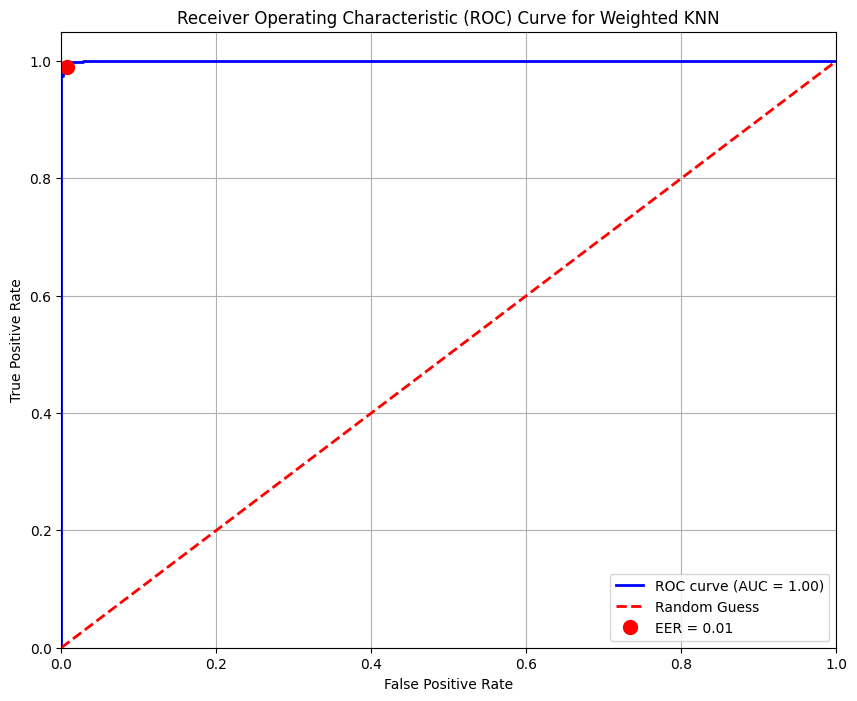

['node1-1', 'node1-20']
Great! Epoch #2 contains more devices than #1, and #1 is a subset of #2. Running open-set for RX: ['node1-1', 'node1-20']
29/29 [==============================] - 0s 2ms/step


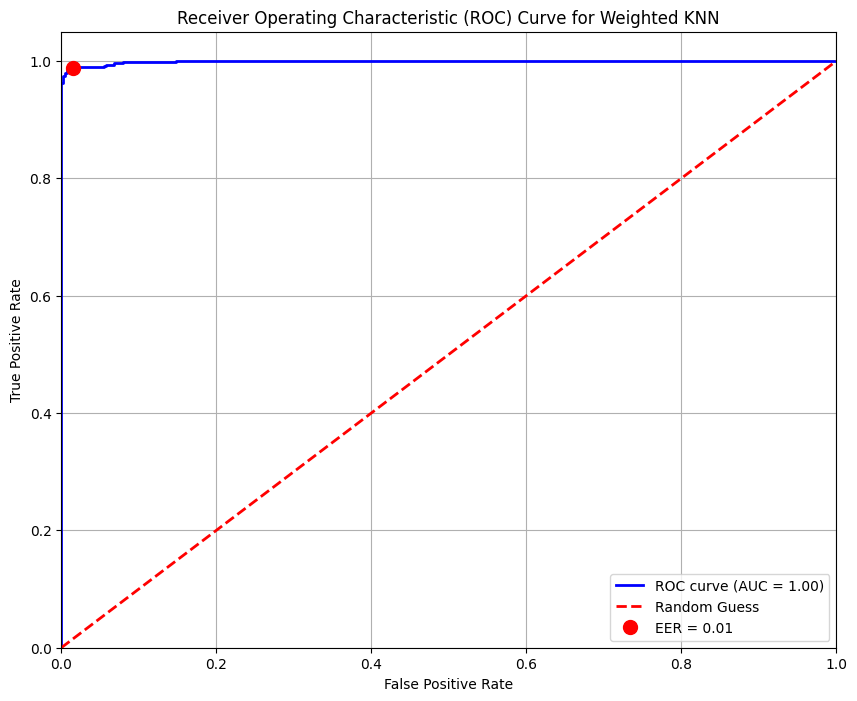

['node1-1', 'node1-20', 'node20-1']
Great! Epoch #2 contains more devices than #1, and #1 is a subset of #2. Running open-set for RX: ['node1-1', 'node1-20', 'node20-1']
29/29 [==============================] - 1s 2ms/step


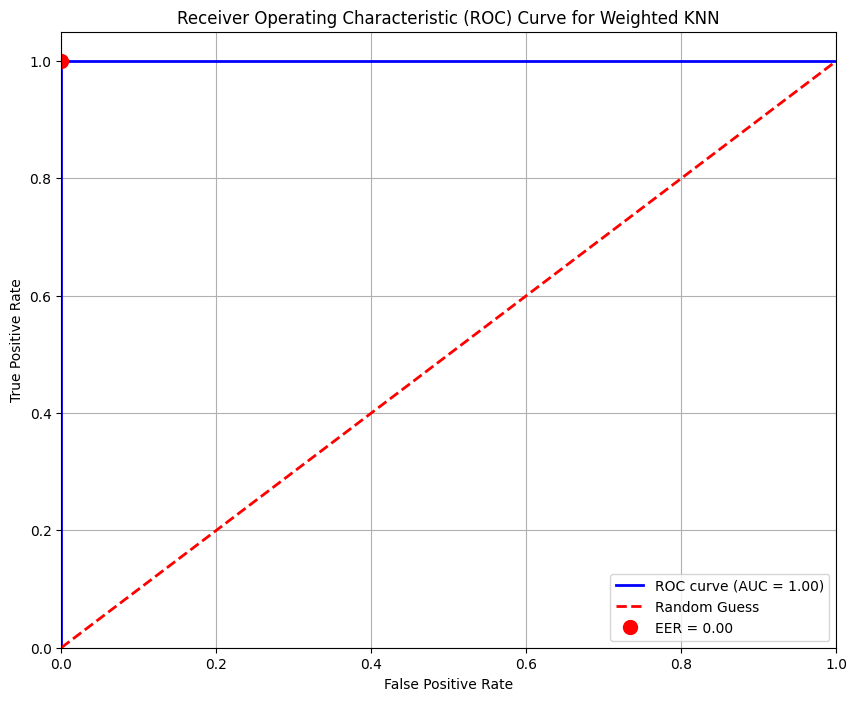

['node1-1', 'node1-20', 'node20-1', 'node19-19']
Great! Epoch #2 contains more devices than #1, and #1 is a subset of #2. Running open-set for RX: ['node1-1', 'node1-20', 'node20-1', 'node19-19']
29/29 [==============================] - 0s 2ms/step


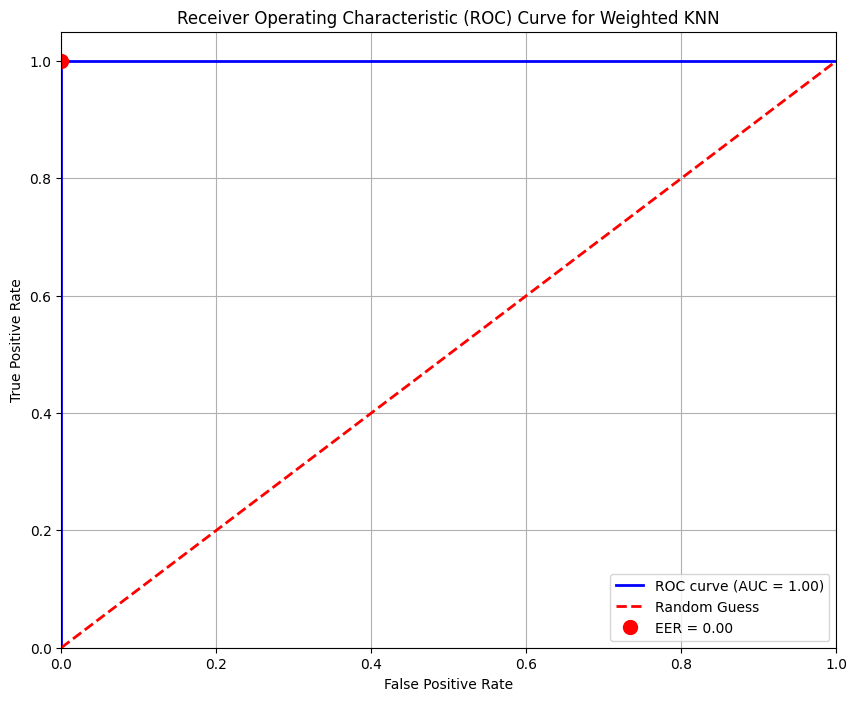

In [12]:
eval_api.evaluate_open_set_knn_multirx(
    models, RX_NODES_V2[0:1], 
    data_epochs_1, labels_epochs_1, 
    data_epochs_2, labels_epochs_2, rssis_epoch_2, 
    MODEL_CONFIG, render_roc_curve=True)

eval_api.evaluate_open_set_knn_multirx(
    models, RX_NODES_V2[0:2], 
    data_epochs_1, labels_epochs_1, 
    data_epochs_2, labels_epochs_2, rssis_epoch_2, 
    MODEL_CONFIG, render_roc_curve=True)

eval_api.evaluate_open_set_knn_multirx(
    models, RX_NODES_V2[0:3], 
    data_epochs_1, labels_epochs_1, 
    data_epochs_2, labels_epochs_2, rssis_epoch_2, 
    MODEL_CONFIG, render_roc_curve=True)

eval_api.evaluate_open_set_knn_multirx(
    models, RX_NODES_V2[0:4], 
    data_epochs_1, labels_epochs_1, 
    data_epochs_2, labels_epochs_2, rssis_epoch_2, 
    MODEL_CONFIG, render_roc_curve=True)

Generating eval finerprints for node1-1...
29/29 [==============================] - 0s 2ms/step


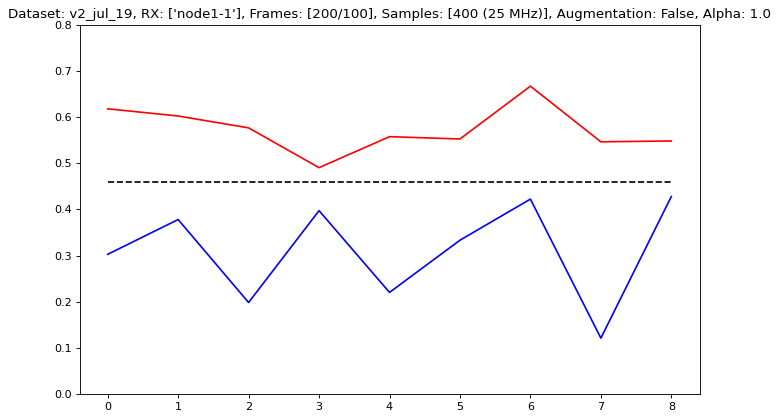

Generating eval finerprints for node1-1...
29/29 [==============================] - 1s 2ms/step
Generating eval finerprints for node1-20...
29/29 [==============================] - 0s 2ms/step


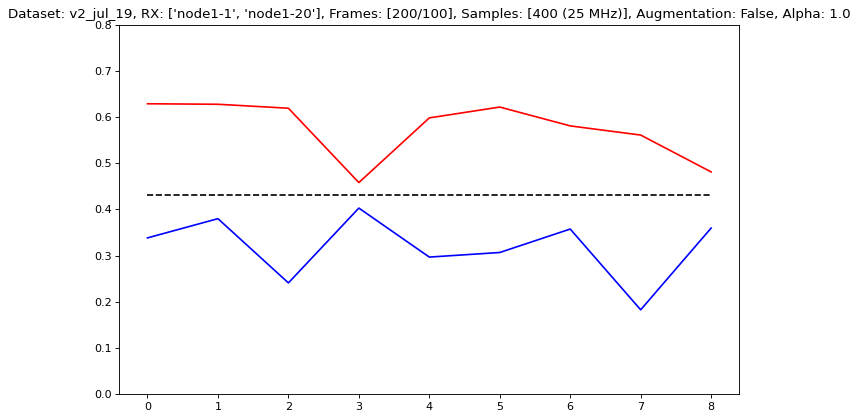

Generating eval finerprints for node1-1...
29/29 [==============================] - 0s 2ms/step
Generating eval finerprints for node1-20...
29/29 [==============================] - 0s 2ms/step
Generating eval finerprints for node20-1...
29/29 [==============================] - 0s 2ms/step


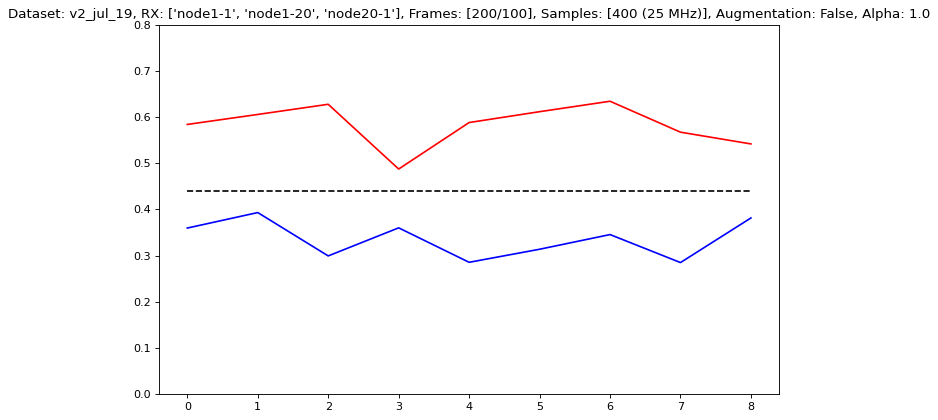

Generating eval finerprints for node1-1...
29/29 [==============================] - 0s 2ms/step
Generating eval finerprints for node1-20...
29/29 [==============================] - 0s 2ms/step
Generating eval finerprints for node20-1...
29/29 [==============================] - 0s 2ms/step
Generating eval finerprints for node19-19...
29/29 [==============================] - 0s 2ms/step


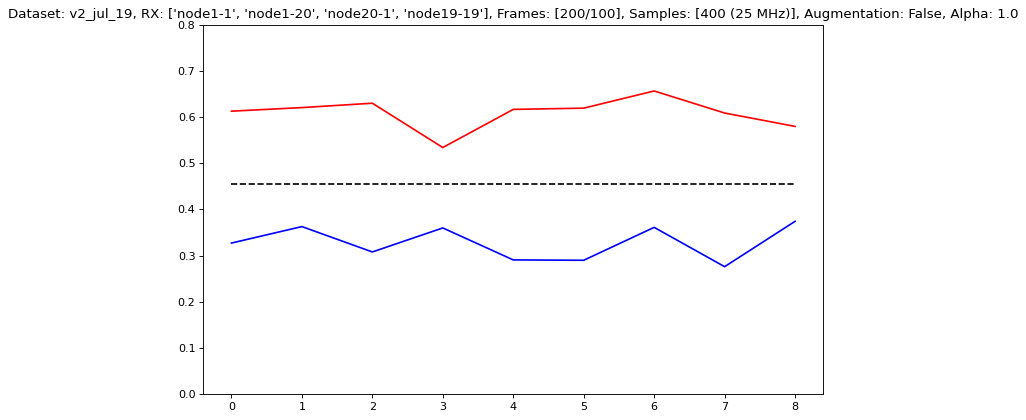

array([[0.32715707, 0.61265195],
       [0.36285629, 0.62041293],
       [0.30794376, 0.6298745 ],
       [0.35989763, 0.53396751],
       [0.2907038 , 0.6165233 ],
       [0.2899241 , 0.61920616],
       [0.36117119, 0.65639567],
       [0.27608077, 0.60866047],
       [0.37424365, 0.57968763]])

In [11]:
epochs = [
    'epoch_2024-07-20_01-15-26',
    'epoch_2024-07-20_01-25-24'
]

eval_api.evaluate_temporal_stability(
    models, RX_NODES_V2[0:1], 
    identify_device_idx, 
    epochs_override=epochs, render_fp_heatmaps=False, render_temporal_heatmap=False)

eval_api.evaluate_temporal_stability(
    models, RX_NODES_V2[0:2], 
    identify_device_idx, 
    epochs_override=epochs, render_fp_heatmaps=False, render_temporal_heatmap=False)

eval_api.evaluate_temporal_stability(
    models, RX_NODES_V2[0:3], 
    identify_device_idx, 
    epochs_override=epochs, render_fp_heatmaps=False, render_temporal_heatmap=False)

eval_api.evaluate_temporal_stability(
    models, RX_NODES_V2[0:4], 
    identify_device_idx, 
    epochs_override=epochs, render_fp_heatmaps=False, render_temporal_heatmap=False)

### 5. Dataset confusion matrices

Enrolling device: (2, 19)
1/1 [==============================] - 0s 23ms/step
This is a new device. New ID: 3ffba528-a07b-4860-8559-ac7e81398d41
{'device_hash': '3ffba528-a07b-4860-8559-ac7e81398d41', 'is_new': True}
Enrolling device: (12, 19)
1/1 [==============================] - 0s 26ms/step


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


1/1 [==============================] - 0s 26ms/step


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


1/1 [==============================] - 0s 25ms/step


...

1/1 [==============================] - 0s 24ms/step


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


1/1 [==============================] - 0s 28ms/step


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 4edaa698-f689-4927-9f8b-0002baabc7fe
{'device_hash': '4edaa698-f689-4927-9f8b-0002baabc7fe', 'is_new': True}
Enrolling device: (14, 20)
1/1 [==============================] - 0s 23ms/step
This is a new device. New ID: 82e5b25f-848f-4765-96c8-0027a105f748
{'device_hash': '82e5b25f-848f-4765-96c8-0027a105f748', 'is_new': True}
Enrolling device: (15, 20)
1/1 [==============================] - 0s 23ms/step
This is a new device. New ID: 75769c58-71a9-4154-9f0b-d6100298cae0
{'device_hash': '75769c58-71a9-4154-9f0b-d6100298cae0', 'is_new': True}
Enrolling device: (16, 15)
1/1 [==============================] - 0s 23ms/step
This is a new device. New ID: e639c208-1f60-4d04-90b6-5c2f3a99dba8
{'device_hash': 'e639c208-1f60-4d04-90b6-5c2f3a99dba8', 'is_new': True}
Enrolling device: (17, 10)
1/1 [==============================] - 0s 25ms/step
This is a new device. New ID: 3b426eaa-1b66-4bd9-ad71-8748565e57aa
{'device_hash': '3b426eaa-1b66-4bd9-ad71-8748565e57aa', 'is_n

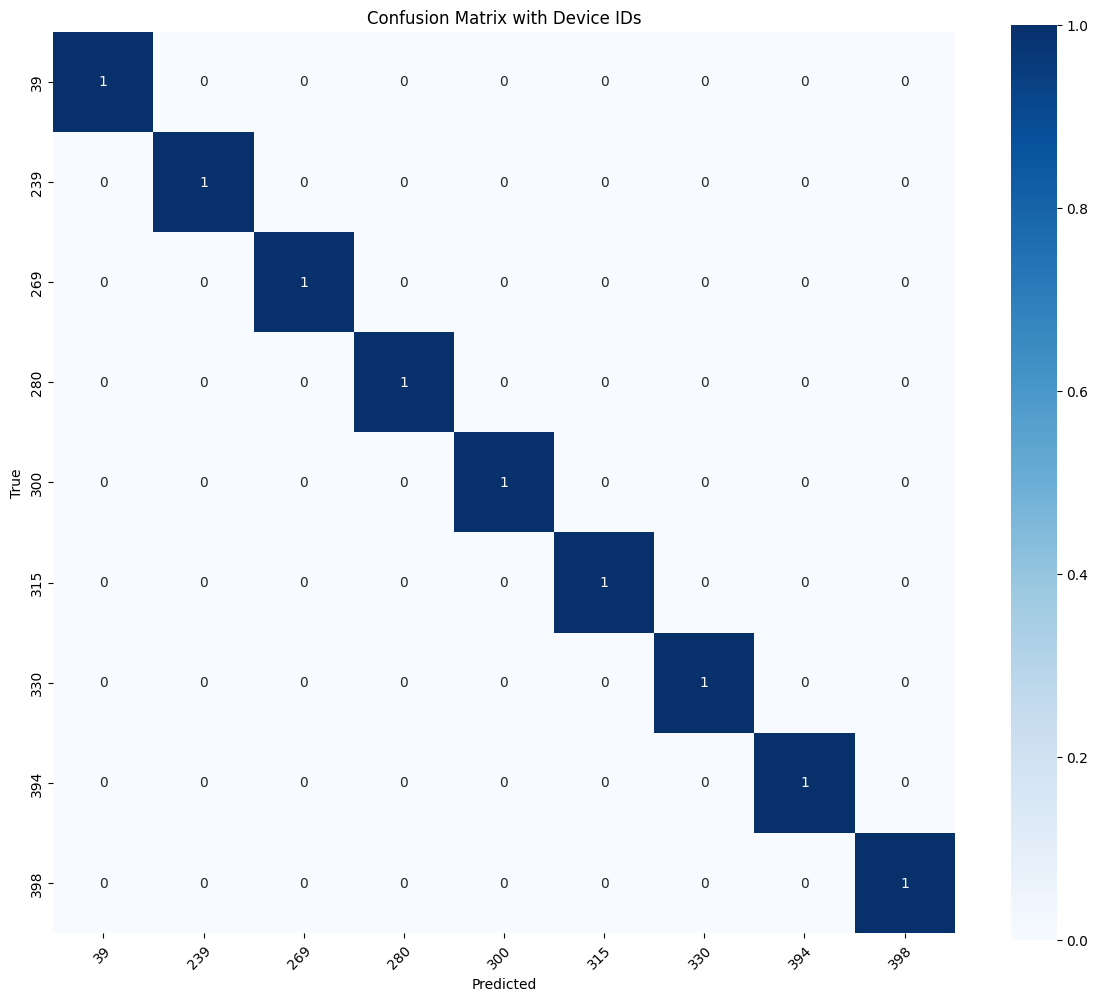

In [25]:
eval_api.evaluate_closed_set_multirx(rx_ids = RX_NODES_V2, 
    epoch_idx_enroll = 0, epoch_idx_identify = 1,
    enroll_device_idx = [39, 239, 269, 280, 300, 315, 330, 394, 398],
    identify_device_idx = [39, 239, 269, 280, 300, 315, 330, 394, 398],
    frame_count_enroll = 10, frame_count_identify = 10,
    enroll_threshold = 0, identify_threshold = 0.55)

## 6. That's all, folks!

Thank you for exploring our project! If you found this useful, please consider citing our paper. This would mean the world to our team.

![](https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExcXhkMmpnZTl0ZmYybWd6NzExMWdxNmY1ZmE4Y2h0d3Zsem96ZG9yMSZlcD12MV9naWZzX3NlYXJjaCZjdD1n/lTpme2Po0hkqI/giphy.gif)

```bibtex
@article{mazokha2024rffi,
  title={RFFI for Mobility Intelligence and MAC Address Derandomization},
  author={Mazokha, Stepan and Bao, Fanchen and Sklivanitis, George and Hallstrom, Jason O},
  journal={TBD},
  year={2024},
  publisher={TBD}
}